# Solari demand forecast
Predict the daily order volume for 1,115 delivery hubs, for the next 42 days.
Score: **RMSLE** = error measured on log(volume + 1).

Put these 4 files in the same folder as this notebook:
- `orders_train.csv` - history, 2013-01-01 to 2015-06-19
- `orders_test.csv` - the 42 days to predict, 2015-06-20 to 2015-07-31
- `hub_metadata.csv` - one row per hub
- `sample_submission.csv` - answer template

At the end you get `submission.csv`.

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb   # if you do not have it:  pip install lightgbm

TRAIN_PATH  = "orders_train.csv"
TEST_PATH   = "orders_test.csv"
META_PATH   = "hub_metadata.csv"
SAMPLE_PATH = "sample_submission.csv"
SUB_PATH    = "submission.csv"

VAL_DAYS = 42   # hold out the same number of days as the test period

plt.rcParams["figure.figsize"] = (10, 4)


def rmsle(y_true, y_pred):
    """The competition metric. Same formula as the scoreboard."""
    y_true = np.clip(np.asarray(y_true, dtype=float), 0, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))


## 1. Load the files

In [2]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
meta = pd.read_csv(META_PATH)
sample = pd.read_csv(SAMPLE_PATH)

train["Date"] = pd.to_datetime(train["Date"])
test["Date"] = pd.to_datetime(test["Date"])

print("train rows:", len(train))
print("test  rows:", len(test))
print("meta  rows:", len(meta))


train rows: 970379
test  rows: 46830
meta  rows: 1115


### The train file

In [3]:
print("columns:", list(train.columns))
print("date range:", train["Date"].min().date(), "to", train["Date"].max().date())
print("hubs:", train["HubID"].nunique())
train.head()


columns: ['HubID', 'Weekday', 'Date', 'OrderVolume', 'AppSessions', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag']
date range: 2013-01-01 to 2015-06-19
hubs: 1115


,HubID,Weekday,Date,OrderVolume,AppSessions,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,2,2013-01-01,0,0,0,0,1,1
1,2,2,2013-01-01,0,0,0,0,1,1
2,3,2,2013-01-01,0,0,0,0,1,1
3,4,2,2013-01-01,0,0,0,0,1,1
4,5,2,2013-01-01,0,0,0,0,1,1


### The test file

In [4]:
print("columns:", list(test.columns))
print("date range:", test["Date"].min().date(), "to", test["Date"].max().date())
print("hubs:", test["HubID"].nunique())
print("rows per day:", test.groupby("Date").size().unique())   # should be one value: 1115
print("closed rows (IsOpen=0):", (test["IsOpen"] == 0).sum())
print("regional holidays:", test["RegionalHoliday"].sum())
test.head()


columns: ['Id', 'HubID', 'Weekday', 'Date', 'IsOpen', 'PromoActive', 'RegionalHoliday', 'SchoolClosureFlag']
date range: 2015-06-20 to 2015-07-31
hubs: 1115
rows per day: [1115]
closed rows (IsOpen=0): 6548
regional holidays: 0


,Id,HubID,Weekday,Date,IsOpen,PromoActive,RegionalHoliday,SchoolClosureFlag
0,1,1,6,2015-06-20,1,0,0,0
1,2,2,6,2015-06-20,1,0,0,0
2,3,3,6,2015-06-20,1,0,0,0
3,4,4,6,2015-06-20,1,0,0,0
4,5,5,6,2015-06-20,1,0,0,0


### The hub metadata file

In [5]:
print("columns:", list(meta.columns))
meta.head()


columns: ['HubID', 'HubFormat', 'AssortmentTier', 'CompetitorDistance', 'CompetitorOpenSinceMonth', 'CompetitorOpenSinceYear', 'LoyaltyProgram', 'LoyaltyProgramSinceWeek', 'LoyaltyProgramSinceYear', 'LoyaltyProgramInterval']


,HubID,HubFormat,AssortmentTier,CompetitorDistance,CompetitorOpenSinceMonth,CompetitorOpenSinceYear,LoyaltyProgram,LoyaltyProgramSinceWeek,LoyaltyProgramSinceYear,LoyaltyProgramInterval
0,1,3,1,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,1,1,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,1,1,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,3,3,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,1,1,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
print("missing values per column:")
print(meta.isna().sum())
print()
print("HubFormat values:", sorted(meta["HubFormat"].unique()))
print("AssortmentTier values:", sorted(meta["AssortmentTier"].unique()))
print("LoyaltyProgram:", meta["LoyaltyProgram"].value_counts().to_dict())
print("loyalty intervals:", meta["LoyaltyProgramInterval"].dropna().unique())


missing values per column:
HubID                         0
HubFormat                     0
AssortmentTier                0
CompetitorDistance            3
CompetitorOpenSinceMonth    354
CompetitorOpenSinceYear     354
LoyaltyProgram                0
LoyaltyProgramSinceWeek     544
LoyaltyProgramSinceYear     544
LoyaltyProgramInterval      544
dtype: int64

HubFormat values: [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
AssortmentTier values: [np.int64(1), np.int64(2), np.int64(3)]
LoyaltyProgram: {1: 571, 0: 544}
loyalty intervals: ['Jan,Apr,Jul,Oct' 'Feb,May,Aug,Nov' 'Mar,Jun,Sept,Dec']


### The sample submission

In [7]:
sample.head()


,Id,OrderVolume
0,1,0
1,2,0
2,3,0
3,4,0
4,5,0


In [8]:
# the Id column must match the test file, row by row
print("rows:", len(sample))
print("same Ids as test, same order:", (sample["Id"].values == test["Id"].values).all())


rows: 46830
same Ids as test, same order: True


## 2. Sanity checks on the train file

Three questions to answer before building anything:
1. What does Weekday number 1 to 7 mean?
2. Is the grid complete (every hub on every day)?
3. Do closed days always have 0 orders?

In [9]:
# 1. one date per weekday number, so we can read off the day of week
train.groupby("Weekday")["Date"].min()


Weekday
1   2013-01-07
2   2013-01-01
3   2013-01-02
4   2013-01-03
5   2013-01-04
6   2013-01-05
7   2013-01-06
Name: Date, dtype: datetime64[ns]

In [10]:
# 2. complete grid?
n_hubs = train["HubID"].nunique()
n_days = train["Date"].nunique()
print("hubs:", n_hubs, " days:", n_days, " rows:", len(train), " expected:", n_hubs * n_days)

# if the grid has holes, rebuild it (closed / not-yet-open days become 0)
if len(train) != n_hubs * n_days:
    print("grid has holes - rebuilding")
    grid = pd.MultiIndex.from_product(
        [train["HubID"].unique(),
         pd.date_range(train["Date"].min(), train["Date"].max())],
        names=["HubID", "Date"]).to_frame(index=False)
    train = grid.merge(train, on=["HubID", "Date"], how="left")
    train["OrderVolume"] = train["OrderVolume"].fillna(0).astype(int)
    for c in ["IsOpen", "PromoActive", "RegionalHoliday", "SchoolClosureFlag"]:
        train[c] = train[c].fillna(0).astype(int)
    train["Weekday"] = train["Date"].dt.dayofweek + 1
    train["AppSessions"] = train["AppSessions"].fillna(0)
    train = train.sort_values(["HubID", "Date"]).reset_index(drop=True)


hubs: 1115  days: 900  rows: 970379  expected: 1003500
grid has holes - rebuilding


In [11]:
# 3. closed days must have 0 orders
bad = train[(train["IsOpen"] == 0) & (train["OrderVolume"] > 0)]
print("closed rows with orders > 0:", len(bad))

print("share of rows with 0 orders:", round((train["OrderVolume"] == 0).mean(), 3))


closed rows with orders > 0: 0
share of rows with 0 orders: 0.199


## 3. Look at the train data

Plots first, numbers second. The goal is to find the patterns a good model must know:
weekday shape, promo lift, school-closure effect, closed hubs, new hubs, trends.

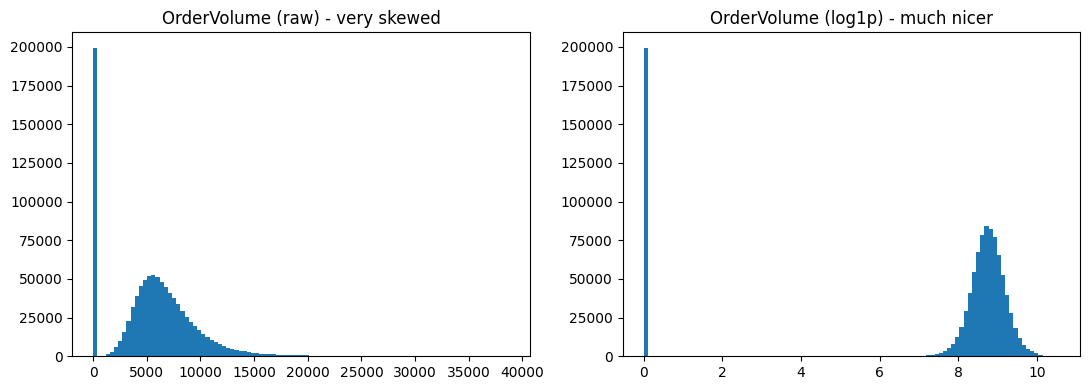

In [12]:
train["y"] = np.log1p(train["OrderVolume"])   # the scale the score uses

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(train["OrderVolume"], bins=100)
ax[0].set_title("OrderVolume (raw) - very skewed")
ax[1].hist(train["y"], bins=100)
ax[1].set_title("OrderVolume (log1p) - much nicer")
plt.tight_layout()
plt.show()


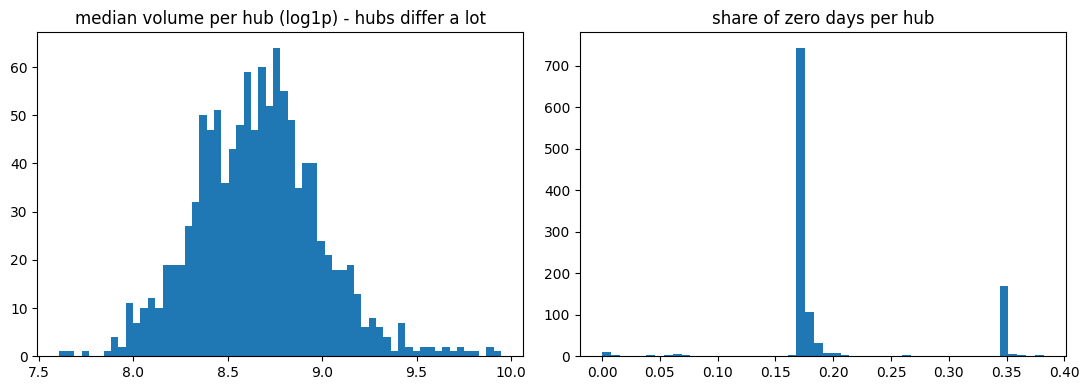

hubs with 0 median volume: 0
hubs with > 50% zero days: 0


In [13]:
hub = train.groupby("HubID").agg(median_vol=("OrderVolume", "median"),
                                 zero_share=("OrderVolume", lambda s: (s == 0).mean()))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].hist(np.log1p(hub["median_vol"]), bins=60)
ax[0].set_title("median volume per hub (log1p) - hubs differ a lot")
ax[1].hist(hub["zero_share"], bins=50)
ax[1].set_title("share of zero days per hub")
plt.tight_layout()
plt.show()

print("hubs with 0 median volume:", (hub["median_vol"] == 0).sum())
print("hubs with > 50% zero days:", (hub["zero_share"] > 0.5).sum())


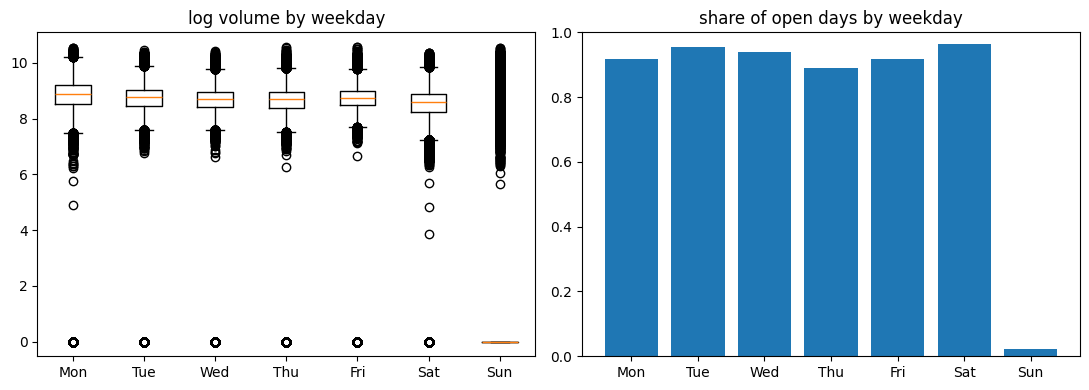

In [14]:
# weekday shape
dow_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].boxplot([train.loc[train["Weekday"] == w, "y"] for w in range(1, 8)],
              tick_labels=dow_names)
ax[0].set_title("log volume by weekday")
ax[1].bar(dow_names, [train.loc[train["Weekday"] == w, "IsOpen"].mean() for w in range(1, 8)])
ax[1].set_title("share of open days by weekday")
ax[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()


mean log volume, no promo: 6.041
mean log volume, promo   : 8.678
overall promo lift (log): 2.637


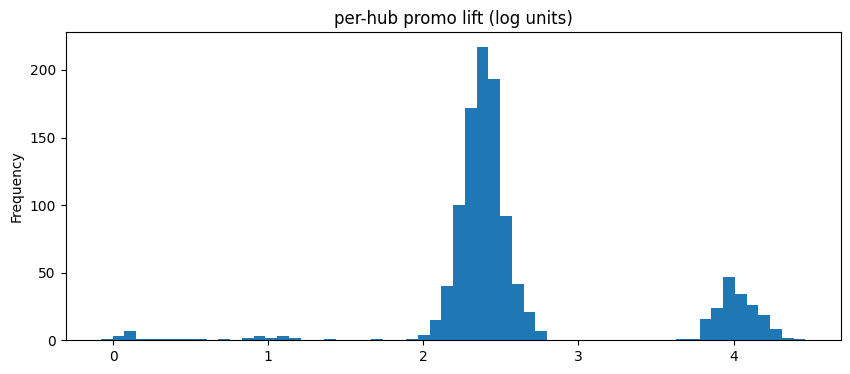

In [15]:
# promo effect: overall, then per hub
mean_no = train.loc[train["PromoActive"] == 0, "y"].mean()
mean_yes = train.loc[train["PromoActive"] == 1, "y"].mean()
print("mean log volume, no promo:", round(mean_no, 3))
print("mean log volume, promo   :", round(mean_yes, 3))
print("overall promo lift (log):", round(mean_yes - mean_no, 3))

# per-hub lift: hub promo mean minus hub normal mean
lift = train.groupby("HubID")["y"].agg(
    p=lambda s: s[train.loc[s.index, "PromoActive"] == 1].mean(),
    n=lambda s: s[train.loc[s.index, "PromoActive"] == 0].mean())
hub_lift = (lift["p"] - lift["n"]).dropna()
hub_lift.plot.hist(bins=60)
plt.title("per-hub promo lift (log units)")
plt.show()


hubs with closure days: 1115


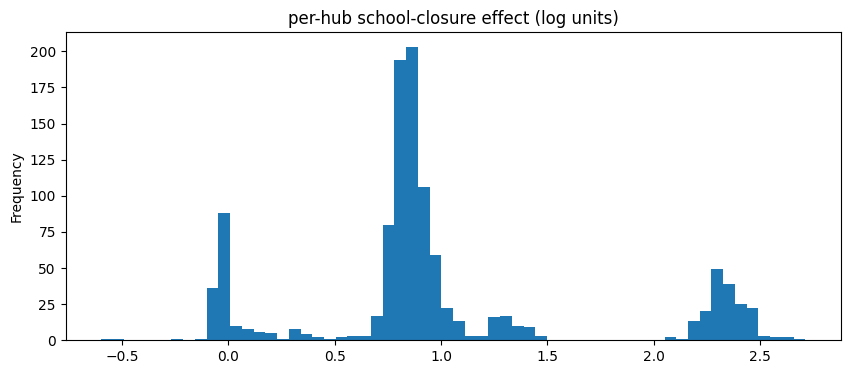

In [16]:
# school closure effect: same idea
sc = train.groupby("HubID")["y"].agg(
    c=lambda s: s[train.loc[s.index, "SchoolClosureFlag"] == 1].mean(),
    n=lambda s: s[train.loc[s.index, "SchoolClosureFlag"] == 0].mean())
hub_sc = (sc["c"] - sc["n"]).dropna()
print("hubs with closure days:", len(hub_sc))
hub_sc.plot.hist(bins=60)
plt.title("per-hub school-closure effect (log units)")
plt.show()


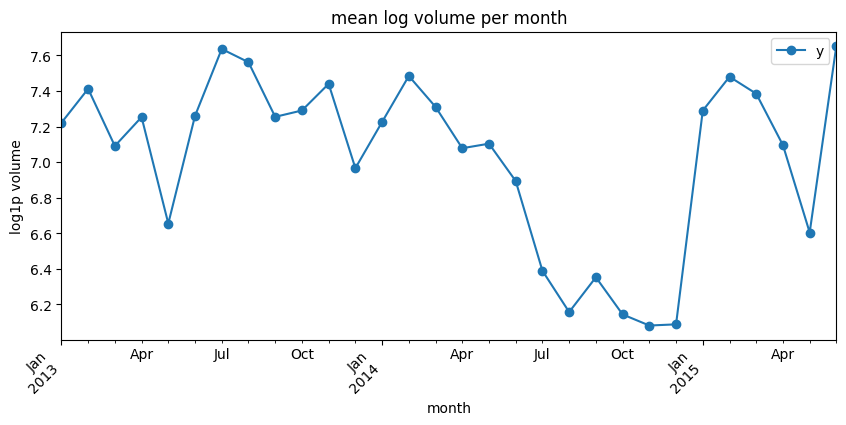

In [17]:
# monthly trend (mean log volume per month)
mt = train.assign(month=train["Date"].dt.to_period("M")).groupby("month")["y"].mean().reset_index()
mt.plot(x="month", y="y", marker="o")
plt.title("mean log volume per month")
plt.ylabel("log1p volume")
plt.xticks(rotation=45, ha="right")
plt.show()


hubs that never sold in the whole history: 0


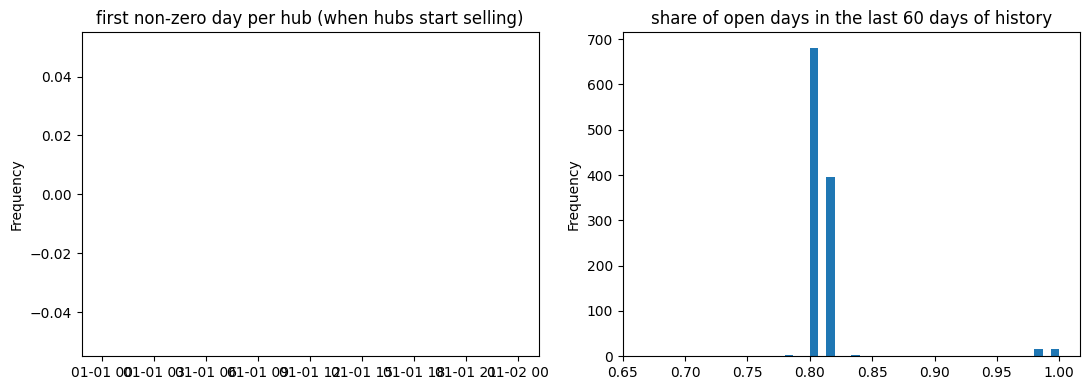

hubs with 0 open days in the last 60: 0


In [18]:
# lifecycle: when did hubs first sell, and who is closed most of the time?
first_nz = train.loc[train["OrderVolume"] > 0].groupby("HubID")["Date"].min()
print("hubs that never sold in the whole history:",
      train["HubID"].nunique() - first_nz.count())

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
first_nz.plot.hist(ax=ax[0], bins=60)
ax[0].set_title("first non-zero day per hub (when hubs start selling)")

last60 = train[train["Date"] >= train["Date"].max() - pd.Timedelta(days=59)]
open60 = last60.groupby("HubID")["IsOpen"].mean()
open60.plot.hist(ax=ax[1], bins=50)
ax[1].set_title("share of open days in the last 60 days of history")
plt.tight_layout()
plt.show()
print("hubs with 0 open days in the last 60:", (open60 == 0).sum())


## 4. Look at the test file

The test dates are not random - they contain known events. Check them with plots.

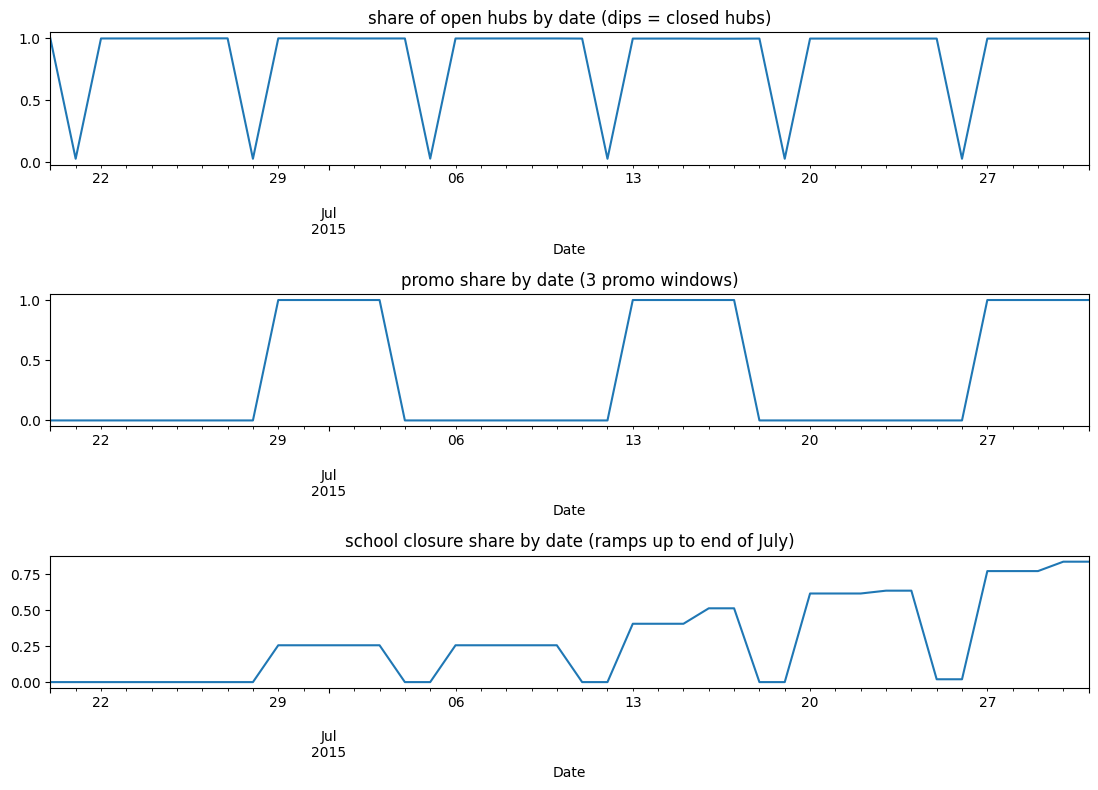

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(11, 8))
(test.groupby("Date")["IsOpen"].mean()).plot(ax=ax[0])
ax[0].set_title("share of open hubs by date (dips = closed hubs)")
(test.groupby("Date")["PromoActive"].mean()).plot(ax=ax[1])
ax[1].set_title("promo share by date (3 promo windows)")
(test.groupby("Date")["SchoolClosureFlag"].mean()).plot(ax=ax[2])
ax[2].set_title("school closure share by date (ramps up to end of July)")
plt.tight_layout()
plt.show()


In [20]:
# which hubs are closed on which days in the test?
closed = test[test["IsOpen"] == 0]
print("closed rows:", len(closed), " over", closed["Date"].nunique(), "days")
print("hubs that are closed at least once:", closed["HubID"].nunique())

by_date = closed.groupby("Date").size()
print("most closed days:")
print(by_date.sort_values(ascending=False).head(8))


closed rows: 6548  over 37 days
hubs that are closed at least once: 1083
most closed days:
Date
2015-06-21    1083
2015-07-19    1083
2015-07-26    1083
2015-07-12    1083
2015-06-28    1083
2015-07-05    1082
2015-07-17       3
2015-07-16       3
dtype: int64


## 5. Metadata vs volume

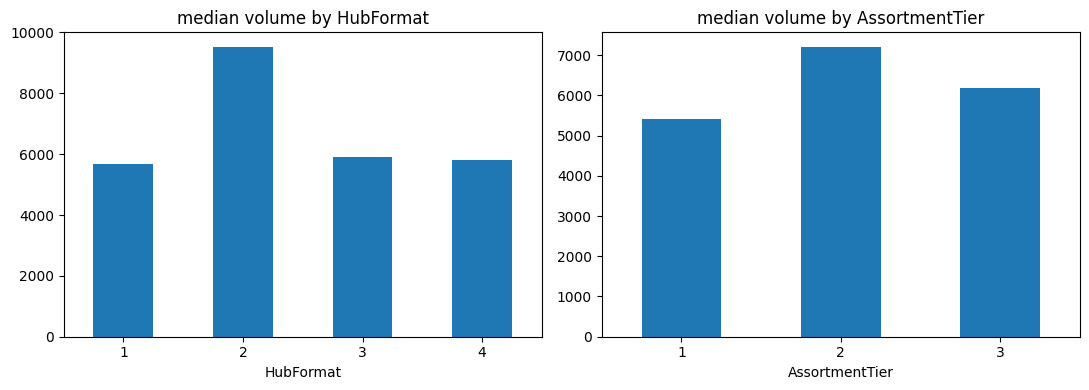

In [21]:
m = meta.merge(hub[["median_vol"]].rename_axis("HubID").reset_index(), on="HubID", how="left")

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
m.groupby("HubFormat")["median_vol"].median().plot(kind="bar", ax=ax[0], rot=0)
ax[0].set_title("median volume by HubFormat")
m.groupby("AssortmentTier")["median_vol"].median().plot(kind="bar", ax=ax[1], rot=0)
ax[1].set_title("median volume by AssortmentTier")
plt.tight_layout()
plt.show()


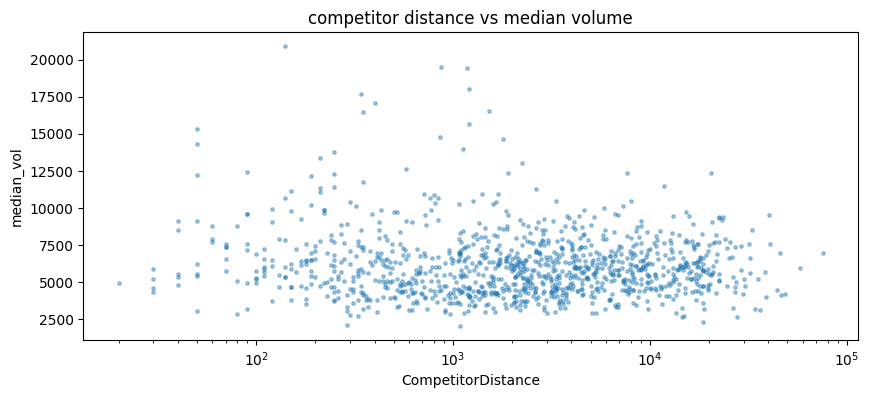

In [22]:
m2 = m.dropna(subset=["CompetitorDistance"])
m2.plot.scatter("CompetitorDistance", "median_vol", s=6, alpha=0.4)
plt.xscale("log")
plt.title("competitor distance vs median volume")
plt.show()


In [23]:
print("median volume by loyalty program:")
print(m.groupby("LoyaltyProgram")["median_vol"].median())
print()
print("median volume by number of loyalty months:")
print(m.assign(n_lm=m["LoyaltyProgramInterval"].fillna("").str.split(",").str.len())
         .groupby("n_lm")["median_vol"].median())


median volume by loyalty program:
LoyaltyProgram
0    6107.0
1    5386.5
Name: median_vol, dtype: float64

median volume by number of loyalty months:
n_lm
1    6107.0
4    5386.5
Name: median_vol, dtype: float64


## 6. Validation split (same shape as the real test)

Hold out the **last 42 days of train** (2015-05-19 to 2015-06-19).
Everything built for those days uses only data from before 2015-05-19.
The RMSLE on these days is our estimate of the real score.

In [24]:
test_start = test["Date"].min()                      # 2015-06-20
val_start  = test_start - pd.Timedelta(days=VAL_DAYS)  # 2015-05-19

print("test window:", test["Date"].min().date(), "to", test["Date"].max().date())
print("val  window:", val_start.date(), "to", (test_start - pd.Timedelta(days=1)).date())

is_val = (train["Date"] >= val_start) & (train["Date"] < test_start)
print("val rows:", is_val.sum(), "  train rows:", (~is_val).sum())


test window: 2015-06-20 to 2015-07-31
val  window: 2015-05-09 to 2015-06-19
val rows: 46830   train rows: 956670


## 7. Features

One table with train + test rows. Each feature for a day only looks at **earlier** days
(done with `.shift(1)` before any rolling mean - that is the no-peeking rule).
Each feature group is its own small function.

In [25]:
# combine train and test into one frame, sorted by hub and date
tr = train.copy()
tr["y"] = np.log1p(tr["OrderVolume"])
tr["is_test"] = 0

te = test.copy()
te["y"] = np.nan          # target unknown on test days
te["is_test"] = 1

df = pd.concat([tr, te], ignore_index=True)
df = df.sort_values(["HubID", "Date"]).reset_index(drop=True)
print("combined rows:", len(df))


combined rows: 1050330


### 7.1 Recent level of each hub

In [26]:
def rolling_levels(d):
    """Mean/median log volume of the last 7 to 112 days, per hub."""
    out = d.copy()
    y = out["y"].shift(1)    # shift so the current day is never included
    for k in (7, 14, 28, 56, 112):
        out[f"volm_{k}"] = y.groupby(out["HubID"]).transform(
            lambda s: s.rolling(k, min_periods=1).mean())
    out["vold_28"] = y.groupby(out["HubID"]).transform(
        lambda s: s.rolling(28, min_periods=1).median())
    # momentum: is the hub growing or shrinking?
    out["mom_28"] = out["volm_28"] - out["volm_56"]
    out["mom_56"] = out["volm_56"] - out["volm_112"]
    return out


df = rolling_levels(df)
df[["HubID", "Date", "y", "volm_7", "volm_28", "volm_56", "mom_28"]].head(3)


,HubID,Date,y,volm_7,volm_28,volm_56,mom_28
0,1,2013-01-01,0.000000,NaN,NaN,NaN,NaN
1,1,2013-01-02,8.618124,0.000000,0.000000,0.000000,0.0
2,1,2013-01-03,8.372861,4.309062,4.309062,4.309062,0.0


### 7.2 The hub's usual level on this weekday

In [27]:
def weekday_level(d):
    """For each hub and weekday: mean log volume of that weekday over the last 182 days."""
    out = d.copy()
    for w in range(1, 8):
        yw = out["y"].where(out["Weekday"] == w).shift(1)
        out[f"hubwd_{w}"] = yw.groupby(out["HubID"]).transform(
            lambda s: s.rolling(182, min_periods=2).mean())
    # pick the column that matches the row's weekday
    out["hubwd"] = np.select(
        [out["Weekday"] == w for w in range(1, 8)],
        [out[f"hubwd_{w}"] for w in range(1, 8)],
        default=np.nan)
    out.drop(columns=[f"hubwd_{w}" for w in range(1, 8)], inplace=True)
    # hub has no history for this weekday yet -> fall back to the 28-day mean
    out["hubwd"] = out["hubwd"].fillna(out["volm_28"])
    return out


df = weekday_level(df)
df[["HubID", "Date", "Weekday", "hubwd"]].head(3)


,HubID,Date,Weekday,hubwd
0,1,2013-01-01,2,NaN
1,1,2013-01-02,3,0.000000
2,1,2013-01-03,4,4.309062


### 7.3 Promo and school-closure effect of each hub

In [28]:
def event_effects(d):
    """Per hub: how much do promo days / school-closure days change volume?
    Estimated from the last 365 days of history, open days only.
    .where() puts NaN on non-matching days, so the rolling means
    average only the right days (multiplying would average in zeros)."""
    out = d.copy()
    v_base = out["y"].where((out["IsOpen"] == 1) & (out["PromoActive"] == 0)).shift(1)
    v_promo = out["y"].where((out["IsOpen"] == 1) & (out["PromoActive"] == 1)).shift(1)
    v_scl = out["y"].where((out["IsOpen"] == 1) & (out["SchoolClosureFlag"] == 1)).shift(1)
    v_scl0 = out["y"].where((out["IsOpen"] == 1) & (out["SchoolClosureFlag"] == 0)).shift(1)

    g = out["HubID"]
    b = v_base.groupby(g).transform(lambda s: s.rolling(365, min_periods=10).mean())
    p = v_promo.groupby(g).transform(lambda s: s.rolling(365, min_periods=5).mean())
    out["promo_uplift"] = (p - b).clip(-1.5, 1.5)

    c = v_scl.groupby(g).transform(lambda s: s.rolling(365, min_periods=5).mean())
    c0 = v_scl0.groupby(g).transform(lambda s: s.rolling(365, min_periods=10).mean())
    out["scl_uplift"] = (c - c0).clip(-1.5, 1.5)
    return out


df = event_effects(df)
df[["HubID", "Date", "PromoActive", "promo_uplift", "scl_uplift"]].head(3)


,HubID,Date,PromoActive,promo_uplift,scl_uplift
0,1,2013-01-01,0,NaN,NaN
1,1,2013-01-02,0,NaN,NaN
2,1,2013-01-03,0,NaN,NaN


### 7.4 Hub lifecycle

In [29]:
def lifecycle(d):
    """When did the hub open, when did it last open, how often is it open?"""
    out = d.copy()

    open_date = out["Date"].where(out["IsOpen"] == 1)
    out["last_open"] = open_date.groupby(out["HubID"]).transform(
        lambda s: s.shift(1).ffill())        # last open day strictly before this row
    out["days_since_open"] = (out["Date"] - out["last_open"]).dt.days
    out["days_since_open"] = out["days_since_open"].fillna(10000).clip(lower=0)
    out["ever_open"] = out["last_open"].notna().astype(int)

    first_open = out.loc[out["IsOpen"] == 1].groupby("HubID")["Date"].min()
    out["age_days"] = (out["Date"] - out["HubID"].map(first_open)).dt.days
    out["age_days"] = out["age_days"].fillna(10000).clip(lower=0)

    open_flag = (out["IsOpen"] == 1).astype(float).shift(1)
    out["open28"] = open_flag.groupby(out["HubID"]).transform(
        lambda s: s.rolling(28, min_periods=1).mean())
    return out


df = lifecycle(df)
df[["HubID", "Date", "ever_open", "days_since_open", "age_days", "open28"]].head(3)


,HubID,Date,ever_open,days_since_open,age_days,open28
0,1,2013-01-01,0,10000.0,0,NaN
1,1,2013-01-02,0,10000.0,0,0.0
2,1,2013-01-03,1,1.0,1,0.5


### 7.5 Hub metadata

In [30]:
MONTHS = {1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr", 5: "May", 6: "Jun",
          7: "Jul", 8: "Aug", 9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"}


def meta_features(d, meta):
    """Static hub info plus a few derived columns."""
    out = d.merge(meta, on="HubID", how="left")
    out["has_competitor"] = out["CompetitorDistance"].notna().astype(int)
    out["comp_log_dist"] = np.log1p(out["CompetitorDistance"].fillna(0))
    out["comp_tenure"] = (out["Date"].dt.year - out["CompetitorOpenSinceYear"]).clip(lower=0).fillna(0)
    out["loyal_tenure"] = (out["Date"].dt.year - out["LoyaltyProgramSinceYear"]).clip(lower=0).fillna(0)
    out["loyal_months"] = out["LoyaltyProgramInterval"].fillna("").str.split(",").str.len().fillna(0)

    # is this month one of the hub's loyalty months?
    cur_month = out["Date"].dt.month.map(MONTHS)
    out["loyal_active_month"] = [
        1 if (iv != "" and m in iv.split(",")) else 0
        for iv, m in zip(out["LoyaltyProgramInterval"].fillna(""), cur_month)]
    return out


df = meta_features(df, meta)
df[["HubID", "Date", "HubFormat", "AssortmentTier", "has_competitor",
    "comp_log_dist", "loyal_months", "loyal_active_month"]].head(3)


,HubID,Date,HubFormat,AssortmentTier,has_competitor,comp_log_dist,loyal_months,loyal_active_month
0,1,2013-01-01,3,1,1,7.147559,1,0
1,1,2013-01-02,3,1,1,7.147559,1,0
2,1,2013-01-03,3,1,1,7.147559,1,0


### 7.6 The full feature list

In [31]:
FEATURES = [
    # recent level and momentum
    "volm_7", "volm_14", "volm_28", "volm_56", "volm_112", "vold_28",
    "mom_28", "mom_56",
    # weekday level and event effects
    "hubwd", "promo_uplift", "scl_uplift",
    # lifecycle
    "days_since_open", "ever_open", "age_days", "open28",
    # calendar and given flags
    "Weekday", "IsOpen", "PromoActive", "RegionalHoliday", "SchoolClosureFlag",
    # metadata
    "HubFormat", "AssortmentTier", "LoyaltyProgram",
    "has_competitor", "comp_log_dist", "comp_tenure",
    "loyal_tenure", "loyal_months", "loyal_active_month",
]

for c in FEATURES:
    df[c] = df[c].astype("float32")

print("features:", len(FEATURES))
df[FEATURES].head(3)


features: 29


,volm_7,volm_14,volm_28,volm_56,volm_112,vold_28,mom_28,mom_56,hubwd,promo_uplift,...,SchoolClosureFlag,HubFormat,AssortmentTier,LoyaltyProgram,has_competitor,comp_log_dist,comp_tenure,loyal_tenure,loyal_months,loyal_active_month
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,3.0,1.0,0.0,1.0,7.147559,5.0,0.0,1.0,0.0
1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,NaN,...,1.0,3.0,1.0,0.0,1.0,7.147559,5.0,0.0,1.0,0.0
2,4.309062,4.309062,4.309062,4.309062,4.309062,4.309062,0.0,0.0,4.309062,NaN,...,1.0,3.0,1.0,0.0,1.0,7.147559,5.0,0.0,1.0,0.0


## 8. Models, from dumb to strong

Every model is scored the same way: RMSLE on the 42 validation days.

In [32]:
tr_mask = df["Date"] < val_start
va_mask = (df["Date"] >= val_start) & (df["Date"] < test_start)
te_mask = df["is_test"] == 1

y_va = df.loc[va_mask, "y"].values
a_va = np.expm1(y_va)   # actual volumes of the val rows - the metric needs volumes, not logs
print("val rows:", va_mask.sum())


val rows: 46830


### 8.1 Baseline: the hub's last-28-day mean

In [33]:
p = df.loc[va_mask, "volm_28"].fillna(0).values
p = np.expm1(np.where(df.loc[va_mask, "IsOpen"] == 1, p, 0))
print("baseline (hub 28d mean)   val RMSLE:", round(rmsle(a_va, p), 4))


baseline (hub 28d mean)   val RMSLE: 1.6831


### 8.2 Simple model: weekday level + promo effect + closure effect

In [34]:
def stat_predict(d):
    """Hub's usual level on this weekday, plus the known event effects of the day."""
    lvl = d["hubwd"].fillna(d["volm_28"]).fillna(0)
    p = (lvl
         + d["promo_uplift"].fillna(0) * d["PromoActive"]
         + d["scl_uplift"].fillna(0) * d["SchoolClosureFlag"])
    p = np.where(d["IsOpen"] == 1, np.clip(p, 0, None), 0)
    return np.expm1(p)


p_stat = stat_predict(df.loc[va_mask])
print("stat model                val RMSLE:", round(rmsle(a_va, p_stat), 4))


stat model                val RMSLE: 0.8927


### 8.3 LightGBM on log1p(volume)

In [35]:
params = {
    "objective": "regression",
    "metric": "rmse",
    "learning_rate": 0.05,
    "num_leaves": 127,
    "min_child_samples": 50,
    "subsample": 0.9,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "reg_lambda": 1.0,
    "seed": 42,
    "n_jobs": -1,
    "verbosity": -1,
}

X_tr = df.loc[tr_mask, FEATURES]
X_va = df.loc[va_mask, FEATURES]

dtrain = lgb.Dataset(X_tr, df.loc[tr_mask, "y"].values)
dval = lgb.Dataset(X_va, y_va, reference=dtrain)
model = lgb.train(params, dtrain, num_boost_round=4000, valid_sets=[dval],
                  callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)])
print("stopped at iteration:", model.best_iteration)

p_gbr = np.expm1(model.predict(X_va))
p_gbr = np.where(df.loc[va_mask, "IsOpen"] == 1, p_gbr, 0)
print("lightgbm                val RMSLE:", round(rmsle(a_va, p_gbr), 4))


Training until validation scores don't improve for 100 rounds
[200]	valid_0's rmse: 0.122771
[400]	valid_0's rmse: 0.122334
[600]	valid_0's rmse: 0.121423
[800]	valid_0's rmse: 0.120728
Early stopping, best iteration is:
[859]	valid_0's rmse: 0.120499
stopped at iteration: 859
lightgbm                val RMSLE: 0.1165


In [36]:
# where does the model stand by row type?
ov = df.loc[va_mask, "IsOpen"] == 1
print("open rows  :", round(rmsle(a_va[ov], p_gbr[ov]), 4), " (n =", int(ov.sum()), ")")
print("closed rows:", round(rmsle(a_va[~ov], p_gbr[~ov]), 4), " (n =", int((~ov).sum()), ")")

# and by hub size? (median volume in the training part)
hub_med = df.loc[tr_mask].groupby("HubID")["y"].median()
big = df.loc[va_mask, "HubID"].map(hub_med) > 5   # log1p units, ~150 orders
print("big hubs   :", round(rmsle(a_va[big], p_gbr[big]), 4))
print("small hubs :", round(rmsle(a_va[~big], p_gbr[~big]), 4))


open rows  : 0.1302  (n = 37473 )
closed rows: 0.0  (n = 9357 )
big hubs   : 0.1165
small hubs : nan


c:\Users\galig\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\galig\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\_methods.py:144: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


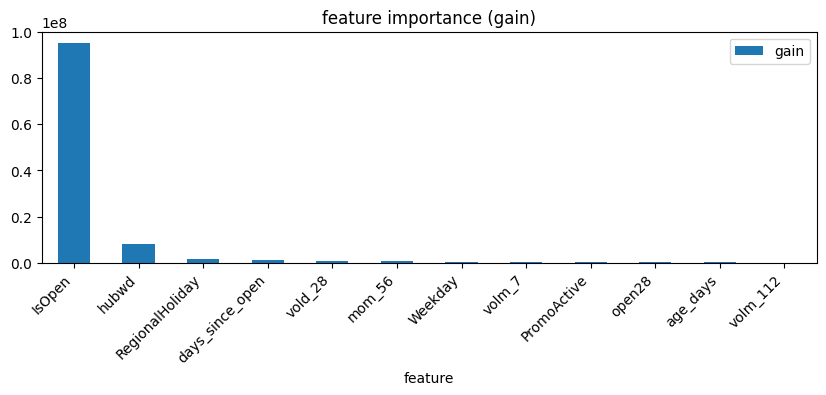

,feature,gain
16,IsOpen,9.539407e+07
8,hubwd,7.962736e+06
18,RegionalHoliday,1.602500e+06
11,days_since_open,1.162269e+06
5,vold_28,6.450981e+05
7,mom_56,6.427582e+05
15,Weekday,4.850124e+05
0,volm_7,2.902077e+05
17,PromoActive,2.405434e+05
14,open28,1.836756e+05


In [37]:
imp = pd.DataFrame({"feature": FEATURES, "gain": model.feature_importance("gain")})
top = imp.sort_values("gain", ascending=False).head(12)
top.plot(x="feature", y="gain", kind="bar", figsize=(10, 3))
plt.xticks(rotation=45, ha="right")
plt.title("feature importance (gain)")
plt.show()
top


### 8.4 Blend the simple model with LightGBM (only if it helps)

In [ ]:
best_w, best_r = 0.0, 1e9
for w in np.arange(0, 1.01, 0.1):
    p = w * p_gbr + (1 - w) * p_stat
    r = rmsle(a_va, p)
    if r < best_r:
        best_w, best_r = w, r
print("best blend: weight on GBR =", round(best_w, 1), " val RMSLE:", round(best_r, 4))

best blend: weight on GBR = 1.0  val RMSLE: 0.1165


### 8.5 The noise floor (can the 0.20 target even be reached?)

In [39]:
# The floor: day-to-day noise around the best prediction, on the val rows.
# No model can go much below this number.
p_best = best_w * p_gbr + (1 - best_w) * p_stat
floor = float(np.std(np.log1p(np.clip(p_best, 0, None)) - y_va))
print("noise floor (std of residual, log units):", round(floor, 4))
print("target 0.20 is", "reachable" if floor <= 0.20 else "above the floor - report this number with evidence")


noise floor (std of residual, log units): 0.1155
target 0.20 is reachable


## 9. Final model and the answer file

Retrain the winner on **all** of train (up to 2015-06-19), predict the 42 test days,
write 0 where the hub is closed, and save `submission.csv`.

In [40]:
X_all = df.loc[df["Date"] < test_start, FEATURES]
y_all = df.loc[df["Date"] < test_start, "y"].values
model_final = lgb.train(params, lgb.Dataset(X_all, y_all),
                        num_boost_round=max(50, model.best_iteration))

p_te = np.expm1(model_final.predict(df.loc[te_mask, FEATURES]))
p_te = best_w * p_te + (1 - best_w) * stat_predict(df.loc[te_mask])
p_te = np.where(df.loc[te_mask, "IsOpen"] == 1, np.clip(p_te, 0, None), 0)

sub = pd.DataFrame({
    "Id": df.loc[te_mask, "Id"].astype(int),
    "OrderVolume": p_te.round(0),
})
sub = sub.sort_values("Id").reset_index(drop=True)   # same order as the sample file
sub.to_csv(SUB_PATH, index=False)
sub.head()


,Id,OrderVolume
0,1,4558.0
1,2,2650.0
2,3,4538.0
3,4,9966.0
4,5,2039.0


## 10. Final checks

In [ ]:
print("rows:", len(sub))
print("Ids match sample, same order:", (sub["Id"].values == sample["Id"].values).all())
print("any NaN:", bool(sub["OrderVolume"].isna().any()))
print("any negative:", bool((sub["OrderVolume"] < 0).any()))
print()
print(sub["OrderVolume"].describe())

rows: 46830
Ids match sample, same order: True
any NaN: False
any negative: False

count    46830.000000
mean      5734.500299
std       3923.536271
min          0.000000
25%       3012.500000
50%       5436.000000
75%       8169.000000
max      27788.000000
Name: OrderVolume, dtype: float64


In [42]:
# seed check: rerun the GBR with 2 other seeds, the score should not jump around
for s in (7, 123):
    m = lgb.train({**params, "seed": s}, lgb.Dataset(X_tr, df.loc[tr_mask, "y"].values),
                  num_boost_round=model.best_iteration)
    p = np.expm1(m.predict(X_va))
    p = np.where(df.loc[va_mask, "IsOpen"] == 1, p, 0)
    print("seed", s, "-> val RMSLE:", round(rmsle(a_va, p), 4))


seed 7 -> val RMSLE: 0.1253
seed 123 -> val RMSLE: 0.1201


## Report
Fill this in with the numbers from the cells above:

| model | val RMSLE |
|---|---|
| hub 28-day mean | ? |
| simple (weekday + events) | ? |
| LightGBM | ? |
| best blend (used for submission) | ? |

Top 5 features by gain: (from the importance plot)

One paragraph on what moved the score the most:
